In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
import bpmeth
from sympy.abc import x, y, s

a_coeffs=[1,"-s**2-1",3,2]
b_coeffs=[3,"s+1",0.2,0.01]

In [3]:
expansion = bpmeth.FieldExpansion(a=a_coeffs, b=b_coeffs)
# Get analytical B field functions
Bx_func, By_func, Bs_func = expansion.get_Bfield(lambdify=True)

In [4]:
# Choose a fixed s value (e.g., s=0 for the magnet center)
s_fixed = 0.1

def ByiBx(x, y):#analytical definition of By + i*Bx at s=s_fixed
    return By_func(x, y, s_fixed) + 1j * Bx_func(x, y, s_fixed)

dkl = bpmeth.harmonics(ByiBx)
bpmeth.print_harmonics(dkl)
bnian=bpmeth.calc_coeffs(dkl)#bn+i*an
bn=bnian.real[:len(b_coeffs)]
an=bnian.imag[:len(a_coeffs)]
print("recovered bn(s=",s_fixed,"):", bn)
print("Original bn(s):", b_coeffs)
print("an(s=",s_fixed,"):", an)
print("Original an(s):", a_coeffs)


k  l=0                       l=1                       l=2                       
 0    3.0000000,   1.0000000    0.0000000,  -0.0000000    0.0000000,  -0.0000000
 1    1.1000000,  -1.0100000    0.0000000,   0.2500000    0.0000000,  -0.0000000
-1    0.0000000,  -1.0100000   -0.0000000,   0.2500000   -0.0000000,  -0.0000000
 2    0.1000000,   1.5000000    0.0000000,  -0.0000000    0.0000000,  -0.0000000
-2   -0.0000000,   1.5000000    0.0000000,  -0.0000000    0.0000000,  -0.0000000
 3    0.0016667,  -0.0000000   -0.0000000,  -0.0000000   -0.0000000,  -0.0000000
-3   -0.0000000,  -0.0000000   -0.0000000,  -0.0000000   -0.0000000,  -0.0000000
 4    0.0000000,   0.0000000    0.0000000,   0.0000000    0.0000000,   0.0000000
-4   -0.0000000,   0.0000000   -0.0000000,   0.0000000   -0.0000000,   0.0000000
recovered bn(s= 0.1 ): [3.   1.1  0.2  0.01]
Original bn(s): [3, 's+1', 0.2, 0.01]
an(s= 0.1 ): [ 1.   -1.01  3.    2.  ]
Original an(s): [1, '-s**2-1', 3, 2]


In [5]:
import sympy

a_coeffs_eval = [sympy.sympify(coeff).subs(s, s_fixed) for coeff in a_coeffs]
print(a_coeffs_eval)
b_coeffs_eval = [sympy.sympify(coeff).subs(s, s_fixed) for coeff in b_coeffs]
print(b_coeffs_eval)

[1, -1.01000000000000, 3, 2]
[3, 1.10000000000000, 0.200000000000000, 0.0100000000000000]


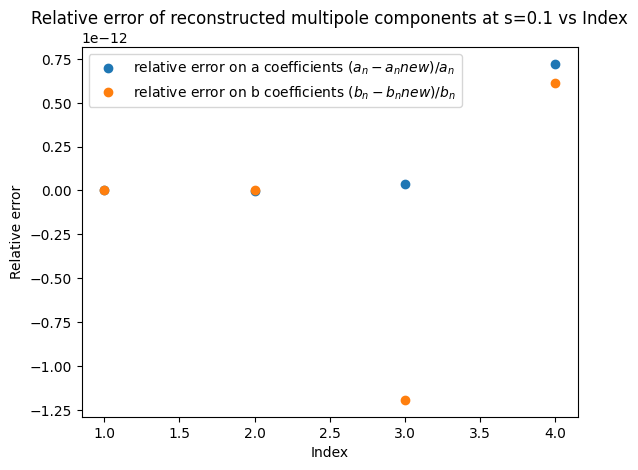

In [6]:
plt.plot(range(1,len(a_coeffs)+1), (a_coeffs_eval-an)/a_coeffs_eval, 'o', label='relative error on a coefficients $(a_n - a_nnew)/a_n$')
plt.xlabel('Index')
plt.ylabel('Relative error')
plt.title('Relative error of reconstructed multipole components at s=' + str(s_fixed) + ' vs Index')
plt.plot(range(1,len(b_coeffs)+1), (b_coeffs_eval-bn)/b_coeffs_eval, 'o', label='relative error on b coefficients $(b_n - b_nnew)/b_n$')
plt.legend()
plt.show()

In [ ]:
#make a fieldmap object
xa= np.linspace(-1,1,101)
ya=np.linspace(-1,1,101)
sa=np.linspace(-1,1,101)
X,Y,S = np.meshgrid(xa, ya, sa)
Bx_ana = Bx_func(X, Y, S)
By_ana = By_func(X, Y, S)
Bs_ana = Bs_func(X, Y, S)
datafieldmap = np.column_stack([
    X.ravel(),
    Y.ravel(),
    S.ravel(),
    Bx_ana.ravel(),
    By_ana.ravel(),
    Bs_ana.ravel()
])
#print("Data shape (N, 6):", datafieldmap.shape)
fm = bpmeth.fieldmaps.Fieldmap(datafieldmap)

In [ ]:
sv, recbn, stdreccoefs = fm.s_harmonics(order=4, rmin=0.01, rmax=1.0)

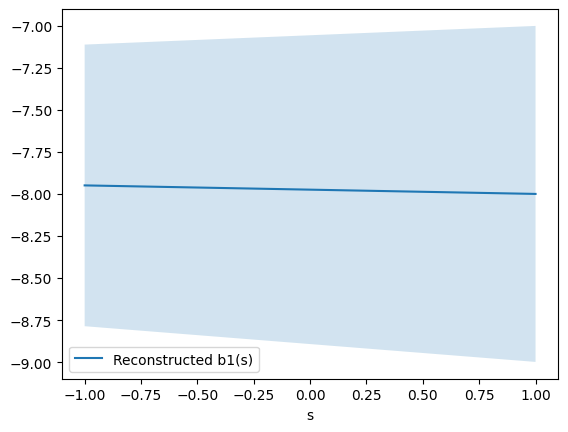

In [ ]:
plt.plot(sv, reccoeffs[:,1], label='Reconstructed b2(s)')
plt.fill_between(sv, reccoeffs[:,1]-stdreccoefs[:,1], reccoeffs[:,1]+stdreccoefs[:,1], alpha=0.2)
plt.xlabel('s')
plt.legend()